In [1]:
#pulling us gdp growth and unemployment rate data from the FRED API and saves it as a standalone file
#it is seperate as it makes this project easier to replicate
#importing relevant libraries 
!pip install fredapi

import pandas as pd
from fredapi import Fred 
from dotenv import load_dotenv
import matplotlib.pyplot as plt 
import os 

load_dotenv('.env')
os.makedirs('~/Desktop', exist_ok=True)
print('ready')

ready


In [3]:
#connecting to FRED
fred_key = os.getenv('FRED_API_KEY') #get a free API key and add it to your .env
assert fred_key, 'FRED_API_KEY not found, check your .env file'

fred = Fred(api_key=fred_key)
print('connected to fred')

connected to fred


In [8]:
#GDP growth rate, (GDPC1) real inflation adjusted that is reported quarterly
#using real gdp so changes reflect actual economic output 
#we take quartely value and compute year over year percentage change as growth rate 

gdp_raw = fred.get_series('GDPC1', observation_start='1974-01-01', observation_end='2025-12-31')
gdp_annual = gdp_raw.resample('YE').last() #quarterly val per year
gdp_annual.index=gdp_annual.index.year
gdp_growth=(gdp_annual.pct_change() * 100).rename('gdp_growth_pct')

print('GDP growth rate for key years:')
print(gdp_growth.loc[[2007, 2008, 2009, 2019, 2020, 2021]].round(2))


GDP growth rate for key years:
2007    2.13
2008   -2.54
2009    0.11
2019    3.35
2020   -0.92
2021    5.76
Name: gdp_growth_pct, dtype: float64


In [10]:
#unemployment rate using civilian unemployment rate (UNRATE) that is reported monthly
#taking annual average 

unemp_raw = fred.get_series('UNRATE', observation_start='1975-01-01', observation_end='2025-12-31')
unemp_annual = unemp_raw.resample('YE').mean()
unemp_annual.index= unemp_annual.index.year
unemp_annual= unemp_annual.rename('unemployment_rate')

print('Unemployment rate for key years:')
print(unemp_annual.loc[[2007, 2008, 2009, 2010, 2019, 2020, 2021]].round(2))

Unemployment rate for key years:
2007    4.62
2008    5.80
2009    9.28
2010    9.61
2019    3.68
2020    8.10
2021    5.35
Name: unemployment_rate, dtype: float64


In [20]:
#building and saving economic data set

df_economic = (
    pd.DataFrame({'year': range(1975, 2026)})
    .set_index('year')
    .join(gdp_growth)
    .join(unemp_annual)
    .reset_index()
    .dropna()
)

#focusing on years where there were recesseion in us, using binary 1: recession, 0 otherwise
#to be used as a binary predictor in regression model 
recession_years = [1975, 1980, 1981, 1982, 1990, 1991, 2001, 2008, 2009, 2020]
df_economic['recession'] = df_economic['year'].isin(recession_years).astype(int)

print(f'Economic dataset: {len(df_economic)} years')
print(df_economic.to_string(index=False))

df_economic.to_csv('~/Desktop/economic_fred.csv', index=False)
print('\nSaved: economic_fred,csv')
      

Economic dataset: 51 years
 year  gdp_growth_pct  unemployment_rate  recession
 1975        2.554795           8.475000          1
 1976        4.311516           7.700000          0
 1977        5.013271           7.050000          0
 1978        6.659560           6.066667          0
 1979        1.284088           5.850000          0
 1980       -0.039052           7.175000          1
 1981        1.299825           7.616667          1
 1982       -1.443184           9.708333          1
 1983        7.899664           9.600000          0
 1984        5.575644           7.508333          0
 1985        4.182460           7.191667          0
 1986        2.907240           7.000000          0
 1987        4.474556           6.175000          0
 1988        3.799339           5.491667          0
 1989        2.743212           5.258333          0
 1990        0.603063           5.616667          1
 1991        1.166401           6.850000          1
 1992        4.382645           7.491

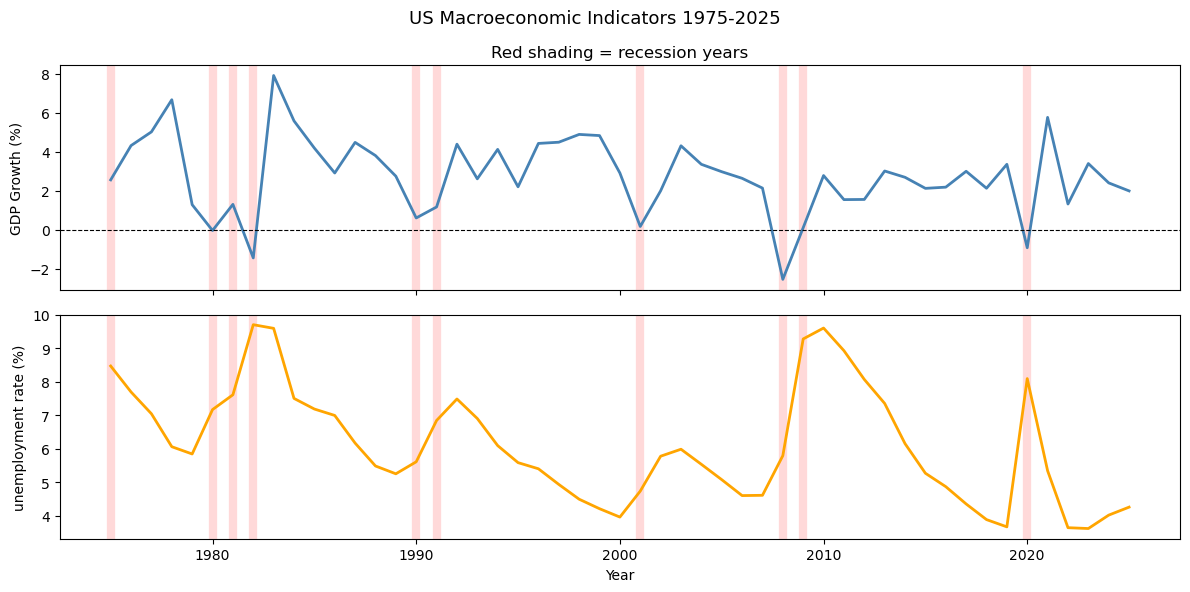

plot saved


In [34]:
#checking if data looks right : visual check 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12,6), sharex=True)
fig.suptitle('US Macroeconomic Indicators 1975-2025', fontsize=13)

for ax in [ax1, ax2]:
    for yr in recession_years:
        ax.axvline(yr, color='red', alpha=0.15, linewidth=6)

ax1.plot(df_economic['year'], df_economic['gdp_growth_pct'], color='steelblue', linewidth=2)
ax1.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax1.set_ylabel('GDP Growth (%)')
ax1.set_title('Red shading = recession years')

ax2.plot(df_economic['year'], df_economic['unemployment_rate'], color='orange', linewidth=2)
ax2.set_ylabel('unemployment rate (%)')
ax2.set_xlabel('Year')

plt.tight_layout()
os.makedirs('~/Desktop/figures', exist_ok=True)
plt.savefig('~/Desktop/figures/economic_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print('plot saved')
